In [1]:
import sys
sys.path.append('/data/coding/MobileSAM/MobileSAMv2')
import numpy as np

In [2]:
from bbq.datasets import get_dataset
from bbq.objects_map import NodesConstructor
import yaml
from tqdm import tqdm

INFO:torch.distributed.nn.jit.instantiator:Created a temporary directory at /tmp/tmpyyjmk_jq
INFO:torch.distributed.nn.jit.instantiator:Writing /tmp/tmpyyjmk_jq/_remote_module_non_scriptable.py


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO:matplotlib.font_manager:generated new fontManager
INFO:faiss.loader:Loading faiss with AVX2 support.
INFO:faiss.loader:Successfully loaded faiss with AVX2 support.


In [3]:
with open('/data/coding/datasets/meeting_room/office_data.yaml') as file:
    config = yaml.full_load(file)

In [4]:
rgbd_dataset = get_dataset(config["dataset"])

In [14]:
nodes_constructor = NodesConstructor(config["nodes_constructor"])

checkpoint_load_scucess


RemoteDisconnected: Remote end closed connection without response

In [ ]:
frame_list=[]

for step_idx in tqdm(range(len(rgbd_dataset))):
    frame=rgbd_dataset[step_idx]

    frame_list.append(frame)
    #if len(frame_list)==10:
    #    break

100%|██████████| 359/359 [00:14<00:00, 24.86it/s]


In [10]:
color, depth, intrinsics, pose = frame_list[90]
mask_result=nodes_constructor.mask_generator(color)


0: 576x1024 18 objects, 64.0ms
Speed: 13.2ms preprocess, 64.0ms inference, 49.1ms postprocess per image at shape (1, 3, 1024, 1024)


In [26]:
xyxy=mask_result['xyxy'][:1]

In [27]:
lt = np.maximum(xyxy[:, None, :2], xyxy[None, :, :2])  # left-top points (N, N, 2)             #### 框之间的左上角交点
rb = np.minimum(xyxy[:, None, 2:], xyxy[None, :, 2:])  # right-bottom points (N, N, 2)         ##   框之间右下角交点
inter = (rb - lt).clip(min=0)

In [30]:
inter[:,:,0]

array([[     182.14]])

In [ ]:
describe=nodes_constructor.features_generator(color)

In [ ]:
describe.shape

torch.Size([63, 113, 384])

In [11]:
detected_objects=nodes_constructor.detections_assembler(90,color,depth,intrinsics,pose,mask_result,describe)

2025-01-08 19:03:57.696 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 0
2025-01-08 19:03:57.699 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 3
2025-01-08 19:03:57.701 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 4
2025-01-08 19:03:57.702 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 9
2025-01-08 19:03:57.703 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 10
2025-01-08 19:03:57.704 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 11
2025-01-08 19:03:57.705 | DEBUG    | bbq.objects_map.detections_assembler:__call__:75 - skipping mask with a low confidence. idx = 12
2025-01-08 19:03:57.706 | DEBUG    | bbq.objects_map.detections_as

In [15]:
detected_objects

[{'pcd': PointCloud with 1510 points.,
  'bbox': OrientedBoundingBox: center: (-0.422444, -0.904604, 3.9307), extent: 1.40591, 0.524334, 0.401878),
  'descriptor': tensor([[ 9.0199e-01,  2.1460e-01,  1.2279e-01,  2.5781e-01,  2.7003e-01,  7.9823e-02, -8.6093e-01, -1.7501e-01, -3.0556e-01,  5.1206e-01,  3.1591e-01, -7.2614e-01,  3.8677e-01, -6.6055e-02, -8.5439e-01,  8.3753e-02,  3.0500e-01,  2.5976e-02,  2.7709e-01,  1.1805e+00, -3.9847e-01,  6.8113e-01,  3.7320e-02,  4.7140e-01,
           -1.6990e-01,  2.2789e-01,  1.0025e-01,  3.8401e-01,  1.7697e-01, -1.2145e+00,  8.5625e-02, -1.5235e-01,  6.9605e-01,  2.8661e-01, -1.2562e+00, -1.4406e-01, -3.4086e-01, -8.3835e-02, -2.4846e-01, -5.8460e-01,  1.0294e+00,  5.6582e-02,  8.7342e-01,  5.2070e-02, -8.8714e-02,  1.6098e+00,  1.1239e+00, -1.2486e+00,
           -7.9253e-02, -2.0704e-01,  1.6529e-02, -2.4313e-01,  4.2860e-01, -2.9125e-01,  4.9205e-01, -5.5732e-01,  5.3858e-01, -4.9279e-02, -3.5572e-01,  1.3583e+00,  8.7847e-01,  3.8390e-02,

In [13]:
mask_result['mask'].shape

(9, 720, 1280)

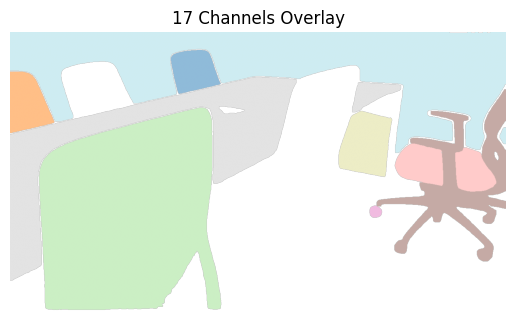

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 假设你的17通道mask图像是一个形状为 (H, W, 17) 的numpy数组

mask=mask_result['mask'].transpose(1,2,0)

# 创建一个空白画布
overlay = np.zeros((720,1280,4))  # RGBA格式，最后一个通道是透明度

# 定义颜色映射
colors = plt.cm.get_cmap('tab20', mask.shape[2])  # 使用tab20颜色映射，支持17种颜色

# 将每个通道叠加到画布上
for i in range(mask.shape[2]):
    color = colors(i)  # 获取颜色
    channel = mask[:, :, i]  # 获取当前通道
    overlay[:, :, 0] += channel * color[0]  # 红色通道
    overlay[:, :, 1] += channel * color[1]  # 绿色通道
    overlay[:, :, 2] += channel * color[2]  # 蓝色通道
    overlay[:, :, 3] += channel * 0.5  # 透明度（可调整）

# 归一化图像，防止值超出范围
overlay = np.clip(overlay, 0, 1)

# 显示叠加后的图像
plt.imshow(overlay)
plt.axis('off')  # 不显示坐标轴
plt.title('17 Channels Overlay')
plt.show()